# Exploratory Analysis: Ghostbuster Corpus

This notebook conducts exploratory analysis of the Ghostbuster corpus 
(Verma et al., 2024) prior to any syntactic parsing. The goal is to 
establish basic corpus statistics, verify the integrity of the dataset, 
and examine surface-level structural features, particularly document 
and sentence length distributions, as a preliminary probe of RQ1: 
whether AI-generated prose exhibits reduced variance and greater 
regularity than human writing.

All heavy parsing (dependency and constituency) is deferred to 
subsequent notebooks. Analysis here uses whitespace tokenisation and 
spaCy's sentence segmenter only.

## Environment Setup

Project root is resolved relative to the notebook location so that 
paths remain portable across machines.

In [2]:
# Set up the environment
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA = PROJECT_ROOT / "data" / "raw" / "ghostbuster-data"
DOMAINS = ["essay", "reuter", "wp"]
SOURCES = ["human", "gpt", "claude"]

## Loading the Corpus

The Ghostbuster dataset is structured as `{domain}/{source}/{id}.txt`, 
with Reuters additionally subdivided by author: 
`reuter/{source}/{author}/{id}.txt`. We load all three domains (essay, 
reuter, wp) and three sources (human, gpt, claude), retaining author 
identity for Reuters documents and setting it to `None` elsewhere.

Several subdirectories are excluded:
- `logprobs/` — token log-probability vectors used by Ghostbuster's 
  own classifier, not prose
- `logprobs_babbage/` - In the essay domain, the gpt source includes an
  extra logprobs folder
- `headlines/` — intermediate GPT prompting artefacts present in the 
  Reuters GPT folder

We load only the same-prompt GPT documents (the `gpt/` folder), 
excluding the four generalisation prompt variants (`gpt_prompt1/2`, 
`gpt_semantic`, `gpt_writing`). This gives the cleanest human/GPT/Claude 
comparison for RQ1, controlling for prompt variation.

In [13]:
# Load the corpus into a DataFrame
def load_corpus() -> pd.DataFrame:
    records = []
    for domain in DOMAINS:
        for source in SOURCES:
            folder = DATA / domain / source
            for path in folder.rglob("*.txt"):
                if "logprobs" in path.parts:
                    continue
                if "logprobs_babbage" in path.parts:
                    continue
                if "headlines" in path.parts:
                    continue
                relative = path.relative_to(folder)
                author = relative.parent.name if len(relative.parts) > 1 else None
                records.append({
                    "id": path.stem,
                    "domain": domain,
                    "source": source,
                    "author": author,
                    "text": path.read_text(encoding="utf-8"),
                })
    return pd.DataFrame(records)

df = load_corpus()

## Serialising the Corpus

Loading ~9,000 files from disk takes several minutes due to filesystem 
overhead. We serialise the DataFrame to Feather format for fast 
subsequent loads (~seconds). Raw data is never modified - only 
`data/processed/` is written to.

On subsequent runs, skip the `load_corpus()` cell and load directly 
from Feather.

In [17]:
df.to_feather(PROJECT_ROOT / "data" / "processed" / "corpus.feather")

In [18]:
df = pd.read_feather(PROJECT_ROOT / "data" / "processed" / "corpus.feather")

## Basic Corpus Statistics

### Document Counts

We first verify the corpus is balanced: 1,000 documents per source 
per domain (9,000 total). Imbalance here would confound any 
distributional comparisons downstream.

In [14]:
# Doc count per domain and source
df.groupby(["domain", "source"]).size()

domain  source
essay   claude    1000
        gpt       1000
        human     1000
reuter  claude    1000
        gpt       1000
        human     1000
wp      claude    1000
        gpt       1000
        human     1000
dtype: int64

The corpus is perfectly balanced at 1,000 documents per cell. 
Combined with the multi-domain design (academic essays, newswire, 
creative writing), this structure allows us to examine syntactic 
feature distributions both within and across domains, directly 
addressing the register confound identified by Baayen et al. (1996) 
as a key threat to validity in stylometric analysis.

### Word Count Distributions

We compute a naive word count per document using whitespace tokenisation 
as a quick length metric. This is sufficient for exploratory purposes -
spaCy tokenisation is reserved for the syntactic analysis. We examine 
mean, variance, and spread per group to check whether document length 
is approximately matched across sources, since length is a known 
confound in syntactic complexity measures.

In [20]:
df["word_count"] = df["text"].str.split().str.len()
df.groupby(["domain", "source"])["word_count"].describe().round(1)

count   mean    std    min    25%    50%    75%     max
domain source                                                          
essay  claude  1000.0  452.8   79.7  250.0  402.0  442.0  497.0   837.0
       gpt     1000.0  565.4  164.6  232.0  427.0  559.0  674.2  1531.0
       human   1000.0  642.0  593.7    0.0  309.8  468.5  681.2  7215.0
reuter claude  1000.0  388.0   52.2  252.0  350.0  384.0  421.0   597.0
       gpt     1000.0  502.8  122.3   51.0  423.8  510.0  588.2  1004.0
       human   1000.0  494.0  131.9   51.0  417.8  498.0  568.0  1335.0
wp     claude  1000.0  389.0  112.9   14.0  313.0  384.0  465.0   852.0
       gpt     1000.0  496.4  210.2   13.0  320.8  511.5  672.2   966.0
       human   1000.0  531.9  358.2  100.0  251.8  455.0  697.5  1835.0

**Findings:**

Claude-generated documents exhibit the lowest within-group variance in 
word count across all three domains (essay σ=79.7, reuter σ=52.2, 
wp σ=112.9), compared to both GPT and human text. Human documents show 
substantially higher variance in all domains, most strikingly in essays 
(σ=593.7), reflecting the unconstrained nature of the IvyPanda source 
material. This length regularity in Claude output is consistent with 
RQ1's hypothesis of reduced variance in AI prose, though document-level 
length is a surface feature - syntactic analysis is required to determine 
whether this regularity extends to sentence structure. One anomalous 
essay document with 0 words requires investigation before proceeding.

In [21]:
df[df["word_count"] == 0]

,id,domain,source,author,text,word_count
202,280,essay,human,NaN,,0
229,304,essay,human,NaN,,0
370,431,essay,human,NaN,,0
730,756,essay,human,NaN,,0
827,843,essay,human,NaN,,0
933,939,essay,human,NaN,,0


In [22]:
df = df[df["word_count"] > 0].reset_index(drop=True)

In [23]:
df.to_feather(PROJECT_ROOT / "data" / "processed" / "corpus.feather")

### Word Count Distributions - Visualisation

We visualise word count distributions as box plots to show median, 
interquartile range, and outliers simultaneously across all nine 
domain/source combinations. Plots are faceted by domain with a shared 
y-axis to allow direct cross-domain comparison. Human, GPT, and Claude 
are ordered consistently left to right in each panel.

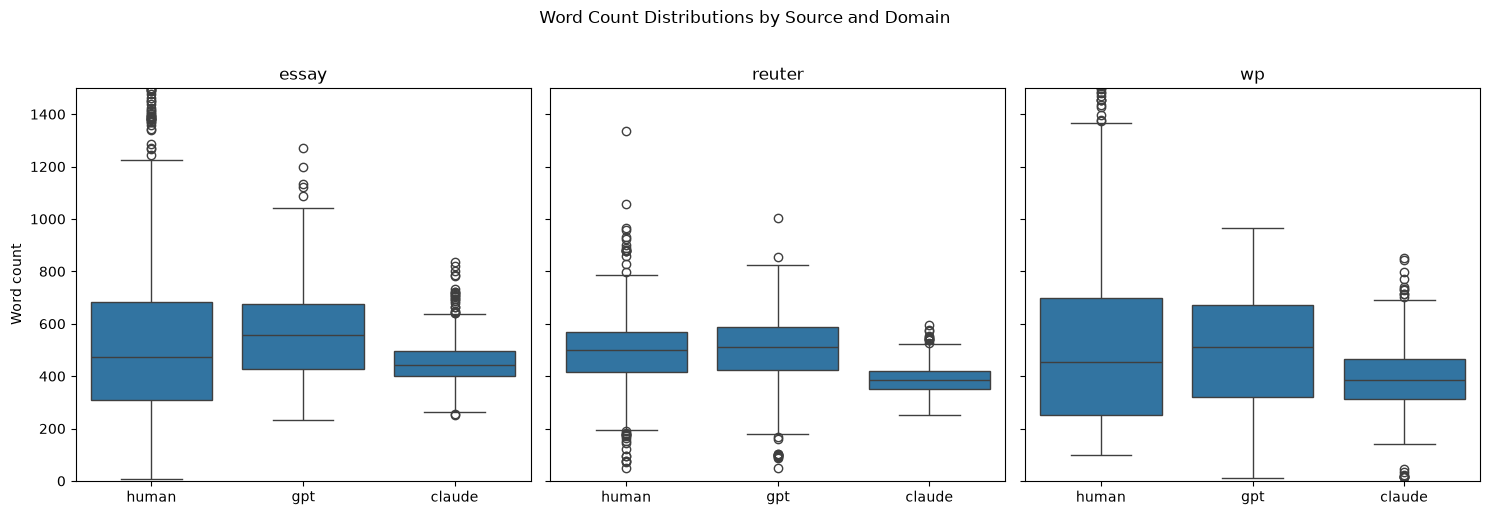

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, domain in zip(axes, DOMAINS):
    subset = df[df["domain"] == domain]
    sns.boxplot(
        data=subset, 
        x="source", 
        y="word_count", 
        ax=ax, 
        order=["human", "gpt", "claude"]
    )
    ax.set_title(domain)
    ax.set_xlabel("")
    ax.set_ylabel("Word count" if ax == axes[0] else "")
    ax.set_ylim(0, 1500)

fig.suptitle("Word Count Distributions by Source and Domain", y=1.02)
plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "results" / "ghostbuster_word_count_distributions.png", 
    dpi=150, bbox_inches="tight"
)
plt.show()

**Findings:**

Three patterns are immediately visible. First, Claude-generated documents 
consistently exhibit the smallest interquartile range across all three 
domains - most strikingly in Reuters, where the Claude box is 
dramatically compressed relative to both human and GPT. This visual 
compression corroborates the descriptive statistics (reuter/claude σ=52.2 
vs reuter/human σ=131.9) and is consistent with RQ1's hypothesis of 
reduced variance in AI-generated prose.

Second, Claude documents are systematically shorter than both human and 
GPT across all domains, suggesting the Claude generation process converges 
on a narrower length range regardless of domain, a form of output 
normalisation not present in GPT to the same degree.

Third, human text shows the widest spread in essay and wp, with long 
upper whiskers and numerous high-word-count outliers, reflecting the 
unconstrained nature of the IvyPanda and r/WritingPrompts source 
material. Reuters is the exception, human and GPT distributions are 
closely matched here, consistent with the constrained register of 
newswire journalism imposing its own length norms independently of 
generation method.

These are surface-level findings based on whitespace tokenisation. 
Whether this document-level length regularity in Claude reflects 
deeper syntactic regularisation - reduced sentence complexity, 
constrained clause structure - is the central question of RQ1 and 
requires parse-level analysis.

## Sentence-Level Statistics

We use spaCy's sentence segmenter to compute per-document sentence 
counts and mean sentence length (in words). We enable only the 
`senter` component (sentence boundary detection) disabling the 
full parser and NER to keep this pass fast. Full dependency and 
constituency parses are deferred to subsequent notebooks.

Mean sentence length and within-document sentence length variance 
are the most directly relevant surface metrics for RQ1: if AI prose 
is syntactically more regular, we would expect lower variance in 
sentence length per document, and potentially shorter, more uniform 
sentences.

In [28]:
import spacy
from tqdm import tqdm

nlp = spacy.load(
    "en_core_web_sm", 
    disable=["tok2vec", "tagger", "parser", "ner", "attribute_ruler", "lemmatizer"]
)
nlp.enable_pipe("senter")

def get_sentence_stats(text: str) -> dict:
    doc = nlp(text)
    sent_lengths = [len(sent.text.split()) for sent in doc.sents]
    return {
        "sent_count": len(sent_lengths),
        "mean_sent_length": pd.Series(sent_lengths).mean(),
        "sent_length_var": pd.Series(sent_lengths).var(),
    }

tqdm.pandas()
stats = df["text"].progress_apply(get_sentence_stats)
df = pd.concat([df, pd.DataFrame(stats.tolist())], axis=1)

100%|██████████| 8994/8994 [03:31<00:00, 42.54it/s] 


In [29]:
df.groupby(
    ["domain", "source"]
)[["sent_count", "mean_sent_length", "sent_length_var"]].describe().round(2)

sent_count                                                \
                   count   mean    std   min    25%   50%   75%    max   
domain source                                                            
essay  claude     1000.0  21.02   4.27   9.0  18.00  21.0  23.0   42.0   
       gpt        1000.0  27.41   7.94  10.0  21.00  27.0  32.0   72.0   
       human       994.0  31.05  28.97   1.0  15.00  22.0  35.0  337.0   
reuter claude     1000.0  14.54   2.98   5.0  12.00  14.0  16.0   26.0   
       gpt        1000.0  20.41   5.58   3.0  16.00  20.0  24.0   45.0   
       human      1000.0  19.48   5.89   2.0  16.00  19.0  23.0   53.0   
wp     claude     1000.0  29.08   9.69   1.0  22.00  28.0  35.0   71.0   
       gpt        1000.0  30.18  13.02   1.0  20.00  31.0  40.0  147.0   
       human      1000.0  40.38  28.50   1.0  19.75  34.0  55.0  177.0   

              mean_sent_length         ...                sent_length_var  \
                         count   mean  ...    75%     max           count   
domain source                          ...                                  
essay  claude           1000.0  21.88  ...  23.84   36.00          1000.0   
       gpt              1000.0  20.78  ...  22.28   44.80          1000.0   
       human             994.0  21.24  ...  23.14   33.32           993.0   
reuter claude           1000.0  27.39  ...  30.07   61.60          1000.0   
       gpt              1000.0  25.00  ...  27.06   43.50          1000.0   
       human            1000.0  25.95  ...  28.33   48.14          1000.0   
wp     claude           1000.0  13.86  ...  15.50   29.62           994.0   
       gpt              1000.0  16.48  ...  17.86  100.00           998.0   
       human            1000.0  14.93  ...  16.18  238.00           997.0   

                                                                       
                 mean     std    min    25%     50%     75%       max  
domain source                                                          
essay  claude   77.44   56.58  11.95  44.30   63.35   94.73    969.54  
       gpt      47.62   81.93  10.45  25.89   33.93   46.55   1898.40  
       human    57.83   76.16   5.24  32.83   44.70   63.81   1797.25  
reuter claude  176.18  162.92  22.14  98.07  143.88  210.10   3905.80  
       gpt      77.31   83.01   4.30  35.98   57.36   91.13   1702.45  
       human   155.12  251.99   4.33  84.57  118.21  171.83   7175.48  
wp     claude   58.48   33.78   4.50  36.89   51.02   71.18    403.92  
       gpt      38.99   21.21   2.04  25.83   34.86   47.15    250.41  
       human   130.99  689.02   0.57  43.85   65.24  107.72  15414.00  

[9 rows x 24 columns]